<a id = "1"></a><br>
# Intro

This notebook aims to demonstrate how to use OPTUNA with XGBoost cv integration.

* Pros:
  * It's fast
  * It allows the pruning of unpromising trials, which makes it even faster
  * It also allows using early stopping

* Cons

  * Sklearn pipeline is not supported.
  
  
  You can check how to tune a sklearn pipeline with OPTUNA in following notebooks.
  
  https://www.kaggle.com/code/rzatemizel/feature-engineering-optuna-stacked-pipe
  
  https://www.kaggle.com/code/rzatemizel/a-late-baseline-guide-to-stacking-pipeline

<a id = "1"></a><br>
# Load Python Pakages


In [1]:
#basics
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from typing import Tuple
warnings.filterwarnings("ignore")


#preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer


#statistics
from scipy import stats
from scipy.stats import skew
from scipy.special import boxcox1p


#feature engineering
from sklearn.feature_selection import mutual_info_classif


#xgboost
import xgboost as xgb

from xgboost import XGBClassifier



#model evaluation
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, log_loss
from sklearn.metrics import make_scorer, accuracy_score, log_loss
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit


random_state = 2343354


<a id = "2"></a><br>
#  First look to data

In [2]:
# Read the data
train = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/train.csv').drop(['Id'], axis=1)
test = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/test.csv').drop(['Id'], axis=1)
greeks = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/greeks.csv').drop(['Id'], axis=1)

# reserved for pipeline
pipe_data = train.copy()
pipe_test = test.copy()


# use for preliminary analysis
train_df = train.copy()
test_df = test.copy()
train_df.head()

,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,4126.58731,...,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,5496.92824,...,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,5135.78024,...,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,4169.67738,...,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,5728.73412,...,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1


In [3]:
test_df.head()

,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,...,FI,FL,FR,FS,GB,GE,GF,GH,GI,GL
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


All zeros?

In [4]:
missing = pd.DataFrame(train_df.isnull().sum().sort_values(ascending=False))
missing.columns = ["count"]
missing = missing.loc[(missing!=0).any(axis=1)]
missing["percent"] = missing[0:] *100 / 617
missing.style.background_gradient('viridis')

,count,percent
EL,60,9.724473
BQ,60,9.724473
CC,3,0.486224
CB,2,0.324149
FS,2,0.324149
FL,1,0.162075
FC,1,0.162075
DU,1,0.162075
GL,1,0.162075


<a id = "3"></a><br>
# Exploratory Data Analysis

In [5]:
# Just bookkeeping
feature_list = [feature for feature in train_df.columns if not feature  == "Class"]

categorical_features= ['EJ']
continuous_features = list(set(feature_list) - set(categorical_features))
assert feature_list.sort() == (continuous_features + categorical_features).sort()

In [6]:
#numerical feature descriptive statistics
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
AB,617.0,0.477149,0.468388,0.081187,0.252107,0.354659,0.559763,6.161666
AF,617.0,3502.013221,2300.322717,192.593280,2197.345480,3120.318960,4361.637390,28688.187660
AH,617.0,118.624513,127.838950,85.200147,85.200147,85.200147,113.739540,1910.123198
AM,617.0,38.968552,69.728226,3.177522,12.270314,20.533110,39.139886,630.518230
AR,617.0,10.128242,10.518877,8.138688,8.138688,8.138688,8.138688,178.943634
AX,617.0,5.545576,2.551696,0.699861,4.128294,5.031912,6.431634,38.270880
AY,617.0,0.060320,0.416817,0.025578,0.025578,0.025578,0.036845,10.315851
AZ,617.0,10.566447,4.350645,3.396778,8.129580,10.461320,12.969516,38.971568
BC,617.0,8.053012,65.166943,1.229900,1.229900,1.229900,5.081244,1463.693448
BD,617.0,5350.388655,3021.326641,1693.624320,4155.702870,4997.960730,6035.885700,53060.599240


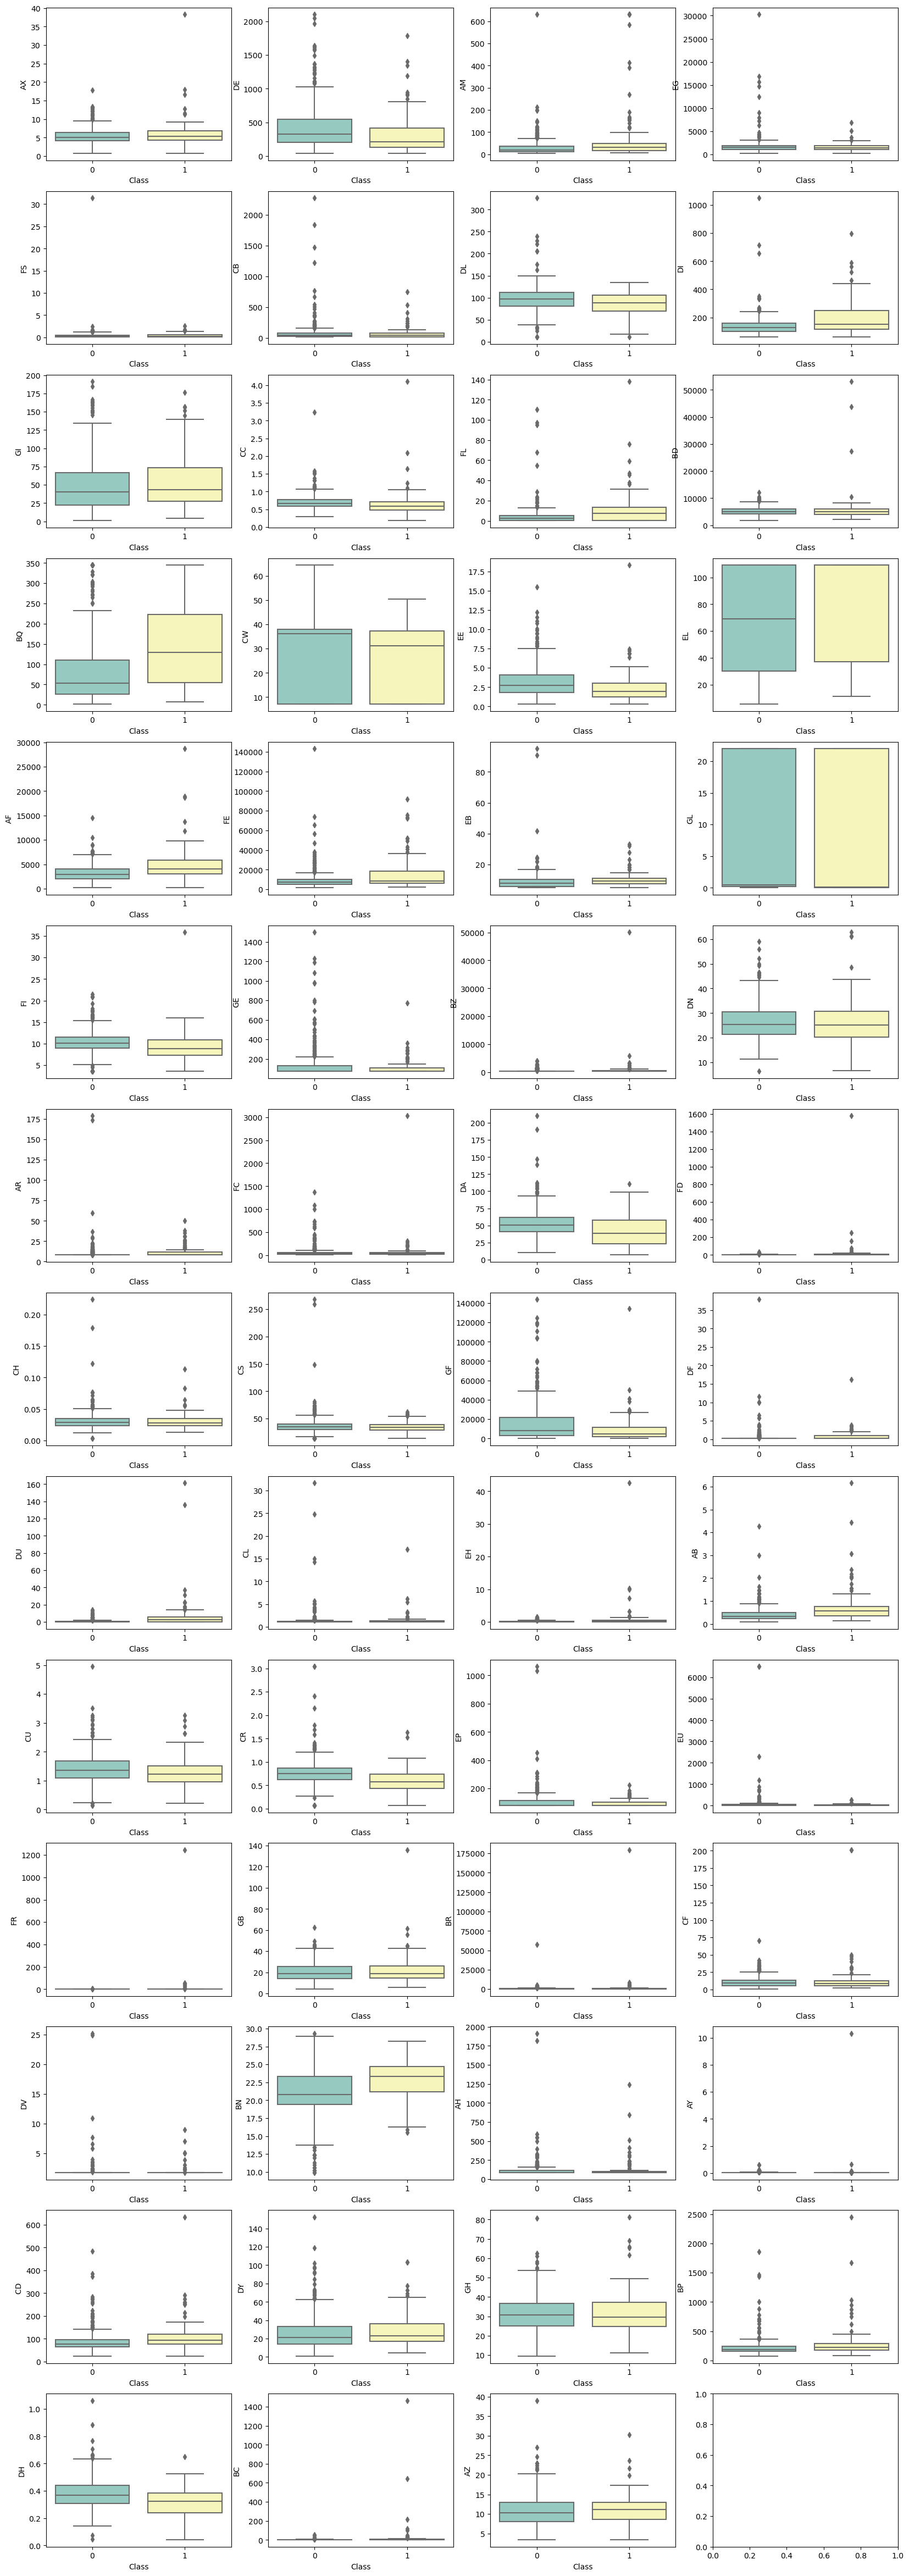

In [7]:

fig, ax = plt.subplots(14, 4, figsize=(20, 60))
for var, subplot in zip(continuous_features, ax.flatten()):
    sns.boxplot(x='Class', y=var,  data=train_df, ax=subplot, palette='Set3')

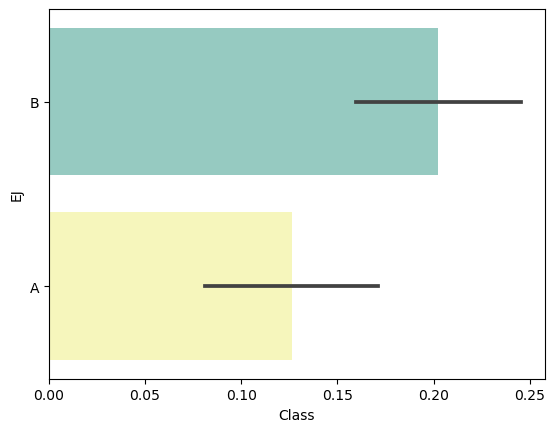

In [8]:
sns.barplot(x='Class', y= 'EJ', data=train_df, palette='Set3')
plt.show()

In [9]:
y= train_df['Class']

In [10]:

# determine the mutual information for numerical features
#You need to fillna to get results from mutual_info_regression function
mutual_df = train_df[continuous_features]

mutual_info = mutual_info_classif(mutual_df.fillna(0), y, random_state= random_state)

mutual_info = pd.Series(mutual_info)
mutual_info.index = mutual_df.columns
pd.DataFrame(mutual_info.sort_values(ascending=False), columns = ["MI_score"] ).style.background_gradient("cool")


,MI_score
DU,0.092863
GL,0.070202
FL,0.068285
BQ,0.057385
AF,0.056244
AB,0.055452
BC,0.054341
DI,0.053539
DA,0.048572
CC,0.048456


In [11]:
mutual_df_categorical = train_df[categorical_features]
#categorical features must be encoded to get mutual information
for colname in mutual_df_categorical:
    mutual_df_categorical[colname], _ = mutual_df_categorical[colname].factorize()
mutual_info = mutual_info_classif(mutual_df_categorical, y, random_state=random_state)

mutual_info = pd.Series(mutual_info)
mutual_info.index = mutual_df_categorical.columns
pd.DataFrame(mutual_info.sort_values(ascending=False), columns = ["Categorical_Feature_MI"] ).style.background_gradient("cool")

,Categorical_Feature_MI
EJ,0


In [12]:
y = pipe_data['Class']
pipe_data = pipe_data.drop(['Class','DY','CB','GB','CH','DL','CU','FS','AZ','GE','EG','EP','EJ'], axis=1) #drop no info columns
pipe_data.head()

,AB,AF,AH,AM,AR,AX,AY,BC,BD,BN,...,FC,FD,FE,FI,FL,FR,GF,GH,GI,GL
0,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,5.555634,4126.58731,22.5984,...,13.394640,10.265073,9028.291921,3.583450,7.298162,1.73855,2003.810319,22.136229,69.834944,0.120343
1,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,1.229900,5496.92824,19.4205,...,17.175984,0.296850,6785.003474,10.358927,0.173229,0.49706,27981.562750,29.135430,32.131996,21.978000
2,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,1.229900,5135.78024,26.4825,...,224.207424,8.745201,8338.906181,11.626917,7.709560,0.97556,13676.957810,28.022851,35.192676,0.196941
3,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,1.229900,4169.67738,23.6577,...,59.301984,7.884336,10965.766040,14.852022,6.122162,0.49706,2094.262452,39.948656,90.493248,0.155829
4,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,102.151980,5728.73412,24.0108,...,29.102640,4.274640,16198.049590,13.666727,8.153058,48.50134,8524.370502,45.381316,36.262628,0.096614


<a id = "3"></a><br>
# Define Competition Metric

In [13]:
# this is how you define custom metric in XGboost
def balancedlogloss(predt: np.ndarray, dtrain: xgb.DMatrix) -> Tuple[str, float]:
    ''' balanced log loss metric.'''
    y = dtrain.get_label()
    target_mean = y.mean()
    w0 = 1/(1-target_mean)
    w1 = 1/target_mean
    sample_weight = [w0 if y == 0 else w1 for y in y]
    loss = log_loss(y, predt, eps = 1e-15, sample_weight=sample_weight)
    
    return 'balancedlogloss', loss

<a id = "3"></a><br>
# Model tunning with optuna XGBoostCV 


In [14]:
# Optuna and visualization tools
import optuna
from optuna.samplers import TPESampler
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_slice

In [15]:
import os
import shutil
CV_RESULT_DIR = "./xgboost_cv_results"

"""
Optuna example that demonstrates a pruner for XGBoost.cv.
a pruner observes intermediate results and stop unpromising trials.
"""

import optuna

import sklearn.datasets
import xgboost as xgb


def objective(trial):
    dtrain = xgb.DMatrix(pipe_data, label=y)

    param = {
        
        "verbosity": 0,
        "objective": "binary:logistic",
        "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        "lambda": trial.suggest_float("lambda", 1e-8, 1.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.2, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 0.8),
        'scale_pos_weight' : 509 / 108,
        'random_state' : random_state,
    }

    if param["booster"] == "gbtree" or param["booster"] == "dart":
        param["max_depth"] = trial.suggest_int("max_depth", 1, 16)
        param["eta"] = trial.suggest_float("eta", 1e-3, 1.0, log=True)
        param["gamma"] = trial.suggest_float("gamma", 1e-8, 1.0, log=True)
        param["grow_policy"] = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])
    if param["booster"] == "dart":
        param["sample_type"] = trial.suggest_categorical("sample_type", ["uniform", "weighted"])
        param["normalize_type"] = trial.suggest_categorical("normalize_type", ["tree", "forest"])
        param["rate_drop"] = trial.suggest_float("rate_drop", 1e-8, 1.0, log=True)
        param["skip_drop"] = trial.suggest_float("skip_drop", 1e-8, 1.0, log=True)
        


    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "test-balancedlogloss")
    history = xgb.cv(param,
                     dtrain,
                     stratified= True,
                     nfold=10,
                     num_boost_round=10000,
                     early_stopping_rounds=100,
                     custom_metric = balancedlogloss,
                     seed = random_state,
                     callbacks=[pruning_callback])

    mean_balancedlogloss = history["test-balancedlogloss-mean"].values[-1]
    trial.set_user_attr("n_estimators", len(history))
    return mean_balancedlogloss


if __name__ == "__main__":
    sampler = TPESampler(seed=random_state) # create a seed for the sampler for reproducibility
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
    study = optuna.create_study( sampler=sampler, pruner=pruner, direction="minimize")
    study.optimize(objective, n_trials=500)

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))
    print("  Number of estimators: {}".format(trial.user_attrs["n_estimators"]))


[I 2023-07-12 06:38:43,012] A new study created in memory with name: no-name-8a5ef008-2ccd-499a-b527-3ca7e9e6e79b
[I 2023-07-12 06:39:15,509] Trial 0 finished with value: 0.5098796 and parameters: {'booster': 'dart', 'lambda': 1.0122380633023929e-05, 'alpha': 1.3202273612151484e-05, 'subsample': 0.2781164983243687, 'colsample_bytree': 0.6758218183388844, 'max_depth': 16, 'eta': 0.5410765497873588, 'gamma': 5.616445675093419e-05, 'grow_policy': 'depthwise', 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 1.185510482789357e-08, 'skip_drop': 0.2527754384673575}. Best is trial 0 with value: 0.5098796.
[I 2023-07-12 06:40:19,854] Trial 1 finished with value: 0.28964880000000004 and parameters: {'booster': 'gbtree', 'lambda': 0.036401940770898894, 'alpha': 0.0029711468501257476, 'subsample': 0.3742863590303537, 'colsample_bytree': 0.5632679048373486, 'max_depth': 2, 'eta': 0.013447942335811765, 'gamma': 0.32402862204415467, 'grow_policy': 'lossguide'}. Best is trial 1 with

Number of finished trials: 500
Best trial:
  Value: 0.28404029999999997
  Params: 
    booster: gbtree
    lambda: 0.12160955907138175
    alpha: 0.006837795298341519
    subsample: 0.6729032706752581
    colsample_bytree: 0.5092927016273839
    max_depth: 3
    eta: 0.2912681708696113
    gamma: 5.719711904630079e-05
    grow_policy: depthwise
  Number of estimators: 22


In [16]:
plot_optimization_history(study)


In [17]:
plot_slice(study)


In [18]:
plot_param_importances(study)


In [19]:
trial

FrozenTrial(number=301, state=TrialState.COMPLETE, values=[0.28404029999999997], datetime_start=datetime.datetime(2023, 7, 12, 6, 53, 29, 241629), datetime_complete=datetime.datetime(2023, 7, 12, 6, 53, 38, 960142), params={'booster': 'gbtree', 'lambda': 0.12160955907138175, 'alpha': 0.006837795298341519, 'subsample': 0.6729032706752581, 'colsample_bytree': 0.5092927016273839, 'max_depth': 3, 'eta': 0.2912681708696113, 'gamma': 5.719711904630079e-05, 'grow_policy': 'depthwise'}, user_attrs={'n_estimators': 22}, system_attrs={}, intermediate_values={0: 0.5897512, 1: 0.5234533, 2: 0.4791274, 3: 0.4487992, 4: 0.4227226, 5: 0.3991589, 6: 0.376196, 7: 0.3544404, 8: 0.34360749999999995, 9: 0.3331163, 10: 0.33112790000000003, 11: 0.3277306, 12: 0.32339480000000004, 13: 0.31701729999999995, 14: 0.31157029999999997, 15: 0.307068, 16: 0.29737559999999996, 17: 0.2928625, 18: 0.2929358, 19: 0.2930292, 20: 0.2905187, 21: 0.28404029999999997, 22: 0.2855027, 23: 0.28703219999999996, 24: 0.29234780000

In [20]:
params={
    'booster': 'gbtree', 'n_estimators': 22, 'lambda': 0.12160955907138175, 'alpha': 0.006837795298341519,
    'subsample': 0.6729032706752581, 'colsample_bytree': 0.5092927016273839, 'max_depth': 3, 
    'eta': 0.2912681708696113, 'gamma': 5.719711904630079e-05, 'grow_policy': 'depthwise' ,
    'scale_pos_weight' : 509 / 108,'random_state' : random_state,"objective": "binary:logistic", 'custom_metric' : balancedlogloss
        }



In [21]:
xgb_tunned = XGBClassifier(**params)


In [22]:
xgb_tunned = xgb_tunned.fit(pipe_data, y)


In [23]:
pipe_test = pipe_test.drop(['DY','CB','GB','CH','DL','CU','FS','AZ','GE','EG','EP','EJ'], axis=1) 

In [24]:
preds_test = xgb_tunned.predict_proba(pipe_test)

### <a id = "13"></a><br>
# Submission

In [25]:
sub = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/sample_submission.csv')
sub[["class_0","class_1"]] = preds_test
sub.to_csv("submission.csv", index=False)
sub

,Id,class_0,class_1
0,00eed32682bb,0.914196,0.085804
1,010ebe33f668,0.914196,0.085804
2,02fa521e1838,0.914196,0.085804
3,040e15f562a2,0.914196,0.085804
4,046e85c7cc7f,0.914196,0.085804
